🔒 Random seed telah dikunci di angka 42. Hasil eksekusi akan selalu sama!
----------------------------------------
Subjek        : SUB4
Kalimat Target: hasilnya sedikit mengejutkan
Shape Matriks : (555, 14) (Time x Channels)

Mengekstraksi fitur Hilbert Spectrum (Stabil karena ada seed lock di dalam loop)...
Memuat model dari SUB4_eq_3_0_fixed_hilbert_best_model_6_1.pt...
✅ Model berhasil dimuat!

Memulai proses decoding RNN-T (Beam Search k=3)...
--------------------------------------------------
[Frame 017/18] Prediksi: hasilnya sedang selamat                 
--------------------------------------------------
Hasil Akhir  : 'hasilnya sedang selamat'
Ground Truth : 'hasilnya sedikit mengejutkan'

Mengintip 3 Semesta Teratas secara Autoregressive:
Step 01 (T=000) | Semesta 1: 'hap' (-1.3)  |  Semesta 2: 'has' (-1.7)  |  Semesta 3: 'pak' (-2.6)  |  
Step 02 (T=001) | Semesta 1: 'hasi' (-1.9)  |  Semesta 2: 'hap' (-2.7)  |  Semesta 3: 'hapi' (-2.9)  |  
Step 03 (T=002) | Semesta 1: 'has

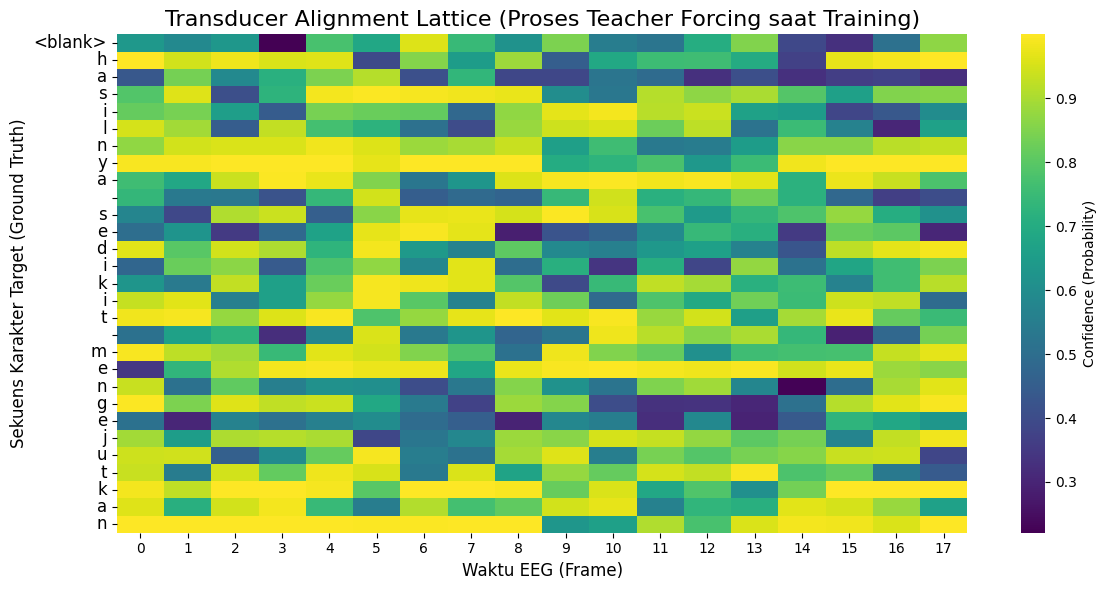

In [ ]:
import os
import sys
import time
import random
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from PyEMD import CEEMDAN
from scipy.signal import hilbert
from sklearn.decomposition import FastICA
from scipy.stats import pearsonr

# ==============================================================================
# 1. PENGUNCIAN SEED GLOBAL (REPRODUCIBILITY)
# ==============================================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Random seed telah dikunci di angka {seed}. Hasil eksekusi akan selalu sama!")

seed_everything(42)

# ==============================================================================
# 2. KONFIGURASI PATH & PARAMETER EKSRAKSI
# ==============================================================================
PROJECT_ROOT = os.path.abspath('../../../') 
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'dataset/raw')
TRAIN_CSV = os.path.join(PROJECT_ROOT, 'dataset/SUB4_eq_3_0_train.csv')

model_path = os.path.join(PROJECT_ROOT, 'src', 'model')
sys.path.insert(0, model_path)
from misc.tokenizer import CharTokenizer

EEG_CHANNELS = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 
                'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 
                'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

CONFIG = {
    'sample_rate': 256, 'hop_length': 8, 'win_length': 16,
    'f_min': 0.2, 'f_max': 45.0, 'ica_threshold': 0.8,
    'start_imf': 2, 'ceemdan_trials': 15, 'n_freq_bins': 65,
}

# ==============================================================================
# 3. PERSIAPAN DATA EEG & TARGET TEKS
# ==============================================================================
df_train = pd.read_csv(TRAIN_CSV)
sample_row = df_train.iloc[0]

id_val = str(sample_row['id'])
subject = sample_row['subject']
gender = sample_row['gender']
ground_truth_sentence = sample_row['sentence']

csv_folder = os.path.join(RAW_DATA_PATH, gender, subject, 'csv')
matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
file_path = os.path.join(csv_folder, matching_files[0])

df_eeg = pd.read_csv(file_path, skiprows=1)
raw_eeg_signal = df_eeg[EEG_CHANNELS].values

print("-" * 40)
print(f"Subjek        : {subject}")
print(f"Kalimat Target: {ground_truth_sentence}")
print(f"Shape Matriks : {raw_eeg_signal.shape} (Time x Channels)")

all_texts = df_train['sentence'].tolist()
tokenizer = CharTokenizer(transcripts=all_texts)
int_tokens = tokenizer.text_to_int(ground_truth_sentence)
tensor_target = torch.LongTensor(int_tokens)

# ==============================================================================
# 4. PEMURNIAN ARTIFAK (ICA) & EKSTRAKSI FITUR (CEEMDAN + HILBERT)
# ==============================================================================
def remove_ocular_artifacts_ica_demo(eeg_signal, ch_names, threshold=0.6):
    frontal_indices = [i for i, ch in enumerate(ch_names) if 'AF3' in ch or 'AF4' in ch]
    ica = FastICA(n_components=eeg_signal.shape[1], random_state=42, max_iter=1000, tol=0.01)
    components = ica.fit_transform(eeg_signal) 
    
    bad_components = []
    for i in range(components.shape[1]):
        is_artifact = False
        for f_idx in frontal_indices:
            corr, _ = pearsonr(components[:, i], eeg_signal[:, f_idx])
            if abs(corr) > threshold:
                is_artifact = True
                break
        if is_artifact: bad_components.append(i)

    components_cleaned = components.copy()
    if bad_components:
        components_cleaned[:, bad_components] = 0.0
        
    cleaned_signal = ica.inverse_transform(components_cleaned)
    return cleaned_signal, bad_components

cleaned_eeg_signal, bad_comps = remove_ocular_artifacts_ica_demo(raw_eeg_signal, EEG_CHANNELS, CONFIG['ica_threshold'])

def compute_hilbert_spectrum_full(eeg_signal, config):
    n_samples, n_channels = eeg_signal.shape
    fs, f_min, f_max, n_bins = config['sample_rate'], config['f_min'], config['f_max'], config['n_freq_bins']
    hop_length, win_length = config['hop_length'], config['win_length']
    start_imf = config.get('start_imf', 2)
    freq_edges = np.linspace(f_min, f_max, n_bins + 1)
    
    # CEEMDAN dengan noise 0.2 seperti saat pelatihan
    # ceemdan = CEEMDAN(trials=config['ceemdan_trials'], noise_scale=0.2, parallel=False)
    ceemdan = CEEMDAN(trials=100, noise_scale=0.2, parallel=False, random_seed=42)
    all_channel_spectra = []
    
    for ch_idx in range(n_channels):
        # KUNCI MUTLAK: np.random.seed di dalam loop untuk konsistensi noise
        np.random.seed(42 + ch_idx)
        
        signal = eeg_signal[:, ch_idx].astype(np.float64)
        imfs = ceemdan(signal)
        imfs = imfs[start_imf:] if start_imf < imfs.shape[0] else imfs[-1:]
        
        hilbert_spec = np.zeros((n_bins, n_samples))
        for i in range(imfs.shape[0]):
            analytic_signal = hilbert(imfs[i])
            amp, phase = np.abs(analytic_signal), np.unwrap(np.angle(analytic_signal))
            freq = (np.diff(phase) / (2.0*np.pi) * fs)
            freq = np.insert(freq, 0, freq[0])
            bin_indices = np.digitize(freq, freq_edges) - 1
            for t in range(n_samples):
                b = bin_indices[t]
                if 0 <= b < n_bins: hilbert_spec[b, t] += (amp[t] ** 2) 
        
        current_n_samples = n_samples
        if current_n_samples > win_length:
            remainder = (current_n_samples - win_length) % hop_length
            if remainder > 0:
                pad_length = hop_length - remainder
                hilbert_spec = np.pad(hilbert_spec, ((0, 0), (0, pad_length)), mode='constant')
                current_n_samples += pad_length

        if current_n_samples < win_length:
            framed_spec = np.zeros((n_bins, 0)) 
        else:
            n_frames = 1 + (current_n_samples - win_length) // hop_length
            framed_spec = np.zeros((n_bins, n_frames))
            for t_idx in range(n_frames):
                start = t_idx * hop_length
                end = start + win_length  
                framed_spec[:, t_idx] = np.mean(hilbert_spec[:, start:end], axis=1)  
        all_channel_spectra.append(framed_spec)
        
    all_channel_spectra = np.array(all_channel_spectra)
    features_transposed = all_channel_spectra.transpose(2, 0, 1)
    features_flat = features_transposed.reshape(features_transposed.shape[0], -1)
    features_flat = np.log(features_flat + 1e-9)
    mean_val, std_val = np.mean(features_flat, axis=0), np.std(features_flat, axis=0)
    features_flat = (features_flat - mean_val) / (std_val + 1e-6)
    
    return features_flat.astype(np.float32)

print("\nMengekstraksi fitur Hilbert Spectrum (Stabil karena ada seed lock di dalam loop)...")
final_features = compute_hilbert_spectrum_full(cleaned_eeg_signal, CONFIG)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
features = torch.FloatTensor(final_features).unsqueeze(0).to(DEVICE)
feature_length = torch.LongTensor([final_features.shape[0]]).to(DEVICE)
targets = tensor_target.unsqueeze(0).to(DEVICE)

# ==============================================================================
# 5. PERSIAPAN & PEMUATAN MODEL (CONFORMER TRANSDUCER)
# ==============================================================================
SUBJECT = 'SUB4'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'src/pipelines/training')
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f'{SUBJECT}_eq_3_0_fixed_hilbert_best_model_6_1.pt')

# Injeksi Dimensi Arsitektur Model
CONFIG['input_dim'] = 14 * 65
CONFIG['encoder_dim'] = 128
CONFIG['decoder_dim'] = 128
CONFIG['joint_dim'] = 128
CONFIG['vocab_size'] = tokenizer.vocab_size()

from model import ConformerTransducer

print(f"Memuat model dari {os.path.basename(BEST_MODEL_PATH)}...")
model = ConformerTransducer(CONFIG).to(DEVICE)

try:
    saved_data = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
    model.eval()
    print("✅ Model berhasil dimuat!")
except FileNotFoundError:
    print(f"❌ ERROR: File model tidak ditemukan di {BEST_MODEL_PATH}")

# ==============================================================================
# 6. DEMONSTRASI & VISUALISASI DENGAN A/B SETS BEAM SEARCH
# ==============================================================================

def live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=3, delay=0.1):
    """Demonstrasi Live selaras dengan beam_decoder_char.py (Menggunakan A/B Sets)"""
    with torch.no_grad():
        device = features.device
        encoder_out = model.encoder(features)
        
        blank_id = 0
        t_max = encoder_out.size(1)
        
        # B = [(list_token_ids, cumulative_score)]
        B = [([blank_id], 0.0)]
        
        print(f"\nMemulai proses decoding RNN-T (Beam Search k={beam_size})...")
        print("-" * 50)
        
        for t in range(t_max):
            f_t = encoder_out[:, t:t+1, :]
            A = B 
            B = []
            
            for sym_count in range(max_sym_per_frame):
                new_A = []
                for token_ids, score in A:
                    y = torch.tensor([token_ids], device=device)
                    g_u, _ = model.decoder(y)
                    g_u_last = g_u[:, -1:, :] 

                    logits = model.joiner(f_t, g_u_last)
                    log_probs = F.log_softmax(logits, dim=-1).view(-1)
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                    
                    for i in range(len(top_ids)):
                        v = top_ids[i].item()
                        p = top_log_probs[i].item()
                        
                        if v == blank_id:
                            B.append((token_ids, score + p))
                        else:
                            new_A.append((token_ids + [v], score + p))
                            
                if not new_A:
                    break
                    
                A = sorted(new_A, key=lambda x: x[1], reverse=True)[:beam_size]
            
            B.extend(A)
            B = sorted(B, key=lambda x: x[1], reverse=True)[:beam_size]
            
            best_ids = B[0][0]
            clean_ids = [i for i in best_ids if i != blank_id]
            current_best_sentence = tokenizer.int_to_text(clean_ids)
            
            print(f"\r[Frame {t:03d}/{t_max}] Prediksi: {current_best_sentence.ljust(40)}", end="")
            time.sleep(delay)
            
        print("\n" + "-" * 50)
        best_ids = B[0][0]
        clean_ids = [i for i in best_ids if i != blank_id]
        final_text = tokenizer.int_to_text(clean_ids)
        print(f"Hasil Akhir  : '{final_text}'")
        print(f"Ground Truth : '{ground_truth_sentence}'\n")

def inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=10, max_sym_per_frame=3):
    """Melihat 3 hipotesis kalimat teratas selaras dengan logika A/B Sets"""
    with torch.no_grad():
        device = features.device
        encoder_out = model.encoder(features)
        
        blank_id = 0
        t_max = encoder_out.size(1)
        B = [([blank_id], 0.0)]
        
        print(f"Mengintip {beam_size} Semesta Teratas secara Autoregressive:")
        print("="*80)
        
        t = 0
        step = 1
        
        while t < t_max and step <= inspect_steps:
            f_t = encoder_out[:, t:t+1, :]
            A = B 
            B = []
            
            for sym_count in range(max_sym_per_frame):
                new_A = []
                for token_ids, score in A:
                    y = torch.tensor([token_ids], device=device)
                    g_u, _ = model.decoder(y)
                    g_u_last = g_u[:, -1:, :] 

                    logits = model.joiner(f_t, g_u_last)
                    log_probs = F.log_softmax(logits, dim=-1).view(-1)
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                    
                    for i in range(len(top_ids)):
                        v = top_ids[i].item()
                        p = top_log_probs[i].item()
                        if v == blank_id:
                            B.append((token_ids, score + p))
                        else:
                            new_A.append((token_ids + [v], score + p))
                            
                if not new_A:
                    break
                A = sorted(new_A, key=lambda x: x[1], reverse=True)[:beam_size]
            
            B.extend(A)
            B = sorted(B, key=lambda x: x[1], reverse=True)[:beam_size]
            
            print(f"Step {step:02d} (T={t:03d}) |", end=" ")
            for i in range(min(beam_size, len(B))):
                score = B[i][1]
                clean_ids = [token for token in B[i][0] if token != blank_id]
                teks = tokenizer.int_to_text(clean_ids) if clean_ids else "<blank>"
                print(f"Semesta {i+1}: '{teks}' ({score:.1f})", end="  |  ")
            print("")
            
            step += 1
            t += 1

def plot_joiner_training_alignment(model, features, targets, tokenizer):
    """Plotting lattice alignment menggunakan Teacher Forcing"""
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        batch_size = targets.shape[0]
        blank_col = torch.zeros((batch_size, 1), dtype=torch.long, device=DEVICE)
        decoder_input = torch.cat([blank_col, targets], dim=1)
        hidden_state = model.decoder.init_hidden(batch_size, DEVICE)
        
        decoder_out, _ = model.decoder(decoder_input, hidden_state)
        
        enc_proj = model.joiner.encoder_proj(encoder_out)
        dec_proj = model.joiner.decoder_proj(decoder_out)
        joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint)
        
        probs = torch.nn.functional.softmax(logits, dim=-1)
        max_probs = probs.max(dim=-1).values[0].cpu().numpy()
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(max_probs.T, cmap='viridis', cbar_kws={'label': 'Confidence (Probability)'})
        
        target_chars = ['<blank>'] + [tokenizer.int_to_text([i.item()])[0] for i in targets[0]]
        plt.yticks(ticks=np.arange(len(target_chars)) + 0.5, labels=target_chars, rotation=0, fontsize=12)
        
        plt.title("Transducer Alignment Lattice (Proses Teacher Forcing saat Training)", fontsize=16)
        plt.xlabel("Waktu EEG (Frame)", fontsize=12)
        plt.ylabel("Sekuens Karakter Target (Ground Truth)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

# ==============================================================================
# EKSEKUSI FUNGSI DEMONSTRASI
# ==============================================================================
# 1. Jalankan animasi Beam Search
live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=3, delay=0.05)

# 2. Intip persaingan 3 hipotesis teratas di 15 langkah pertama
inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=15, max_sym_per_frame=3)

# 3. Buat plot Heatmap
plot_joiner_training_alignment(model, features, targets, tokenizer)

Memulai proses decoding RNN-T (Sesuai cara kerja asli)...

--------------------------------------------------
[Frame 018/18] Prediksi: aku akan di merunga
--------------------------------------------------
Hasil Akhir  : aku akan di merunga
Ground Truth : hasilnya sedikit mengejutkan
Mengintip 3 tebakan teratas secara Autoregressive (Sesuai Inferensi Asli):
Step 01 (T=000) | #1: 'a' (35.6%)  |  #2: 's' (25.8%)  |  #3: 'h' (12.4%)  |   --> Terpilih: 'a'
Step 02 (T=000) | #1: 'k' (50.3%)  |  #2: 'p' (35.7%)  |  #3: 's' (6.8%)  |   --> Terpilih: 'k'
Step 03 (T=000) | #1: 'u' (42.1%)  |  #2: 'a' (41.9%)  |  #3: '<blank>' (11.2%)  |   --> Terpilih: 'u'
Step 04 (T=000) | #1: '<blank>' (75.7%)  |  #2: ' ' (24.3%)  |  #3: 'a' (0.0%)  |   --> Terpilih: '<blank>'
Step 05 (T=001) | #1: ' ' (73.5%)  |  #2: '<blank>' (26.5%)  |  #3: 'a' (0.0%)  |   --> Terpilih: ' '
Step 06 (T=001) | #1: 'a' (69.7%)  |  #2: '<blank>' (8.1%)  |  #3: 's' (6.6%)  |   --> Terpilih: 'a'
Step 07 (T=001) | #1: 'k' (45.2%)

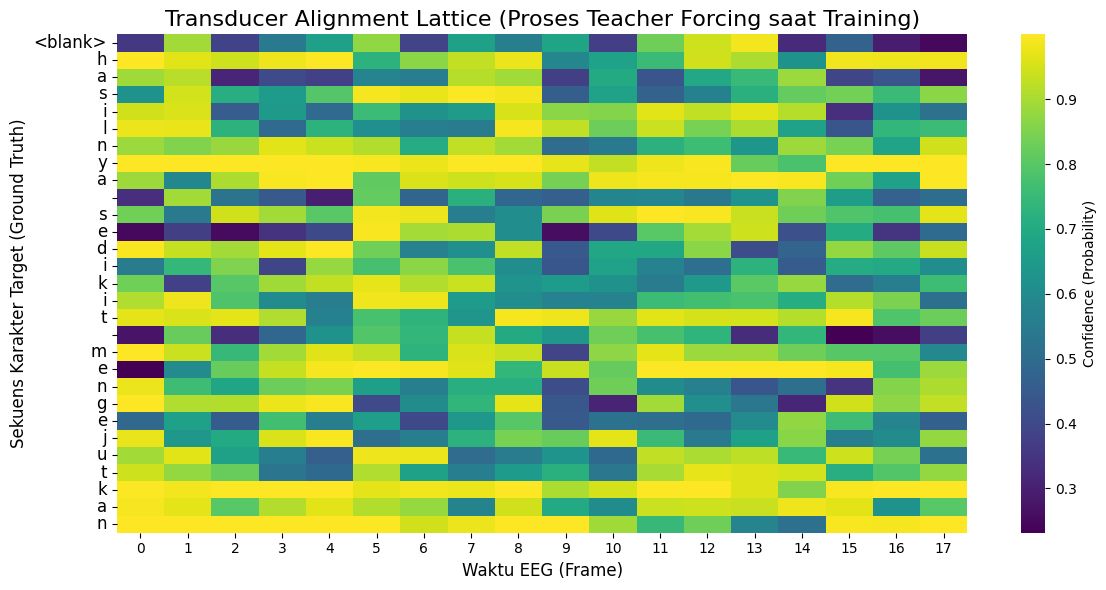

In [50]:
def live_greedy_decode_demo(model, features, tokenizer, delay=0.1, max_sym_per_frame=15):
    """Mendemonstrasikan inferensi RNN-Transducer sejati secara live"""
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        # Inisialisasi
        decoder_input = torch.tensor([[0]], dtype=torch.long, device=DEVICE)
        hidden_state = model.decoder.init_hidden(1, DEVICE)
        predicted_chars = []
        
        t = 0
        sym_count = 0 # Penghitung huruf berturut-turut di frame yang sama
        
        print("Memulai proses decoding RNN-T (Sesuai cara kerja asli)...\n")
        print("-" * 50)
        
        # Loop berhenti jika sudah mencapai frame EEG terakhir
        while t < encoder_out.size(1):
            current_enc_frame = encoder_out[:, t:t+1, :]
            decoder_out, next_hidden_state = model.decoder(decoder_input, hidden_state)
            
            enc_proj = model.joiner.encoder_proj(current_enc_frame)
            dec_proj = model.joiner.decoder_proj(decoder_out)
            joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
            joint = model.joiner.activation(joint)
            logits = model.joiner.output_proj(joint)
            
            prob = torch.nn.functional.softmax(logits, dim=-1)
            predicted_idx = prob.argmax(dim=-1).item()
            
            # KEPUTUSAN RNN-TRANSDUCER SEJATI
            if predicted_idx != 0 and sym_count < max_sym_per_frame:
                # 1. Tebak huruf (Bukan Blank)
                char = tokenizer.int_to_text([predicted_idx])[0]
                predicted_chars.append(char)
                
                # 2. Update ingatan dekoder
                decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long, device=DEVICE)
                hidden_state = next_hidden_state
                
                # 3. TETAP DI FRAME YANG SAMA (t tidak ditambah)
                sym_count += 1
            else:
                # Jika Blank diprediksi: MAJU KE FRAME BERIKUTNYA
                t += 1
                sym_count = 0 # Reset penghitung huruf
            
            current_sentence = "".join(predicted_chars)
            print(f"\r[Frame {t:03d}/{encoder_out.size(1)}] Prediksi: {current_sentence}", end="")
            time.sleep(delay)
            
        print("\n" + "-" * 50)
        print(f"Hasil Akhir  : {''.join(predicted_chars)}")
        print(f"Ground Truth : {ground_truth_sentence}")

live_greedy_decode_demo(model, features, tokenizer, delay=0.05)

def inspect_top_k_candidates(model, features, tokenizer, top_k=3, inspect_steps=10):
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        decoder_input = torch.tensor([[0]], dtype=torch.long, device=DEVICE)
        hidden_state = model.decoder.init_hidden(1, DEVICE)
        
        print(f"Mengintip {top_k} tebakan teratas secara Autoregressive (Sesuai Inferensi Asli):")
        print("="*80)
        
        t = 0
        sym_count = 0
        step = 1
        
        while t < encoder_out.size(1) and step <= inspect_steps:
            current_enc_frame = encoder_out[:, t:t+1, :]
            decoder_out, next_hidden_state = model.decoder(decoder_input, hidden_state)
            
            enc_proj = model.joiner.encoder_proj(current_enc_frame)
            dec_proj = model.joiner.decoder_proj(decoder_out)
            joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
            joint = model.joiner.activation(joint)
            logits = model.joiner.output_proj(joint)
            
            probs = torch.nn.functional.softmax(logits, dim=-1)[0, 0, 0, :]
            top_probs, top_indices = torch.topk(probs, top_k)
            
            print(f"Step {step:02d} (T={t:03d}) |", end=" ")
            for i in range(top_k):
                char_idx = top_indices[i].item()
                char_val = tokenizer.int_to_text([char_idx])[0] if char_idx != 0 else '<blank>'
                prob_val = top_probs[i].item() * 100
                print(f"#{i+1}: '{char_val}' ({prob_val:.1f}%)", end="  |  ")
            
            # Eksekusi rute teratas untuk update state selanjutnya
            predicted_idx = top_indices[0].item()
            print(f" --> Terpilih: '{tokenizer.int_to_text([predicted_idx])[0] if predicted_idx != 0 else '<blank>'}'")
            
            if predicted_idx != 0 and sym_count < 15:
                decoder_input = torch.tensor([[predicted_idx]], dtype=torch.long, device=DEVICE)
                hidden_state = next_hidden_state
                sym_count += 1
            else:
                t += 1
                sym_count = 0
                
            step += 1

inspect_top_k_candidates(model, features, tokenizer, top_k=3, inspect_steps=50)

def plot_joiner_training_alignment(model, features, targets, tokenizer):
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        # Teacher Forcing (Khas Proses Training)
        batch_size = targets.shape[0]
        blank_col = torch.zeros((batch_size, 1), dtype=torch.long, device=DEVICE)
        decoder_input = torch.cat([blank_col, targets], dim=1)
        hidden_state = model.decoder.init_hidden(batch_size, DEVICE)
        
        decoder_out, _ = model.decoder(decoder_input, hidden_state)
        
        enc_proj = model.joiner.encoder_proj(encoder_out)
        dec_proj = model.joiner.decoder_proj(decoder_out)
        joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint)
        
        probs = torch.nn.functional.softmax(logits, dim=-1)
        max_probs = probs.max(dim=-1).values[0].cpu().numpy()
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(max_probs.T, cmap='viridis', cbar_kws={'label': 'Confidence (Probability)'})
        
        target_chars = ['<blank>'] + [tokenizer.int_to_text([i.item()])[0] for i in targets[0]]
        plt.yticks(ticks=np.arange(len(target_chars)) + 0.5, labels=target_chars, rotation=0, fontsize=12)
        
        plt.title("Transducer Alignment Lattice (Proses Teacher Forcing saat Training)", fontsize=16)
        plt.xlabel("Waktu EEG (Frame)", fontsize=12)
        plt.ylabel("Sekuens Karakter Target (Ground Truth)", fontsize=12)
        
        plt.tight_layout()
        plt.show()

plot_joiner_training_alignment(model, features, targets, tokenizer)